In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mfaisalqureshi/hr-analytics-and-job-prediction/HR_comma_sep.csv


# Salifort Motors — Employee Retention Project

**Author:** El khlife Messoud  
**Framework:** PACE (Plan → Analyze → Construct → Execute)

## 🎯 Business problem

The HR department of **Salifort Motors** faces high employee turnover, which is costly in terms of recruitment, onboarding, and lost productivity. They want to understand **what drives employees to leave** and build a predictive system to identify at-risk employees before it's too late.

## 📊 Dataset

HR Analytics and Job Prediction — **14,999 employees** and 10 variables covering satisfaction, performance, workload, tenure, salary, and department.

**Target variable:** `left` (1 = employee left, 0 = employee stayed).  
**Class distribution:** ~83% stayed / ~17% left → **imbalanced dataset** addressed with SMOTE on the training set only.

## 🗂️ Approach (PACE)

| Stage | Action |
|-------|--------|
| **Plan** | Business framing, dataset audit, target identification |
| **Analyze** | EDA, deduplication, IQR outlier detection, 6 visualizations segmenting profiles |
| **Construct** | One-hot encoding, stratified 80/20 split, SMOTE, Random Forest + GridSearchCV |
| **Execute** | Test metrics, confusion matrix, feature importance, decision tree |

In [2]:
# ============================================================
# SALIFORT MOTORS - EMPLOYEE RETENTION PROJECT
# Author: El khlife Messoud
# Framework: PACE (Plan -> Analyze -> Construct -> Execute)
# ============================================================

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from imblearn.over_sampling import SMOTE

# Display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

# Load dataset
df0 = pd.read_csv("/kaggle/input/datasets/mfaisalqureshi/hr-analytics-and-job-prediction/HR_comma_sep.csv")
print(f"Shape: {df0.shape}")
df0.head()

Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# ========== 2. ANALYZE - Data cleaning ==========

# Standardize column names to snake_case
df0 = df0.rename(columns={
    'Work_accident': 'work_accident',
    'average_montly_hours': 'average_monthly_hours',
    'Department': 'department'
})

# Check missing values and duplicates
print(f"Missing values: {df0.isna().sum().sum()}")
print(f"Duplicates: {df0.duplicated().sum()}")

# Remove duplicates (implausible given continuous variables)
df = df0.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after dedup: {df.shape}")

# Outlier detection on tenure using IQR
q25, q75 = df['time_spend_company'].quantile([0.25, 0.75])
iqr = q75 - q25
lower, upper = q25 - 1.5 * iqr, q75 + 1.5 * iqr
outliers = df[(df['time_spend_company'] < lower) | (df['time_spend_company'] > upper)]
print(f"Tenure outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

# Class balance
print("\nClass balance:")
print(df['left'].value_counts(normalize=True).round(4))

Missing values: 0
Duplicates: 3008
Shape after dedup: (11991, 10)
Tenure outliers: 824 rows (6.87%)

Class balance:
left
0    0.834
1    0.166
Name: proportion, dtype: float64


## 📌 Initial observations

- **3,008 duplicated rows removed** — given continuous features (satisfaction_level, last_evaluation), identical rows are implausible and likely data-entry errors
- **824 outliers detected** on tenure (>5 years) but **kept** — Random Forest is robust to outliers, and these points represent critical employee profiles
- **~16.6% positive class** — will be addressed with SMOTE on the training set only (never on test)

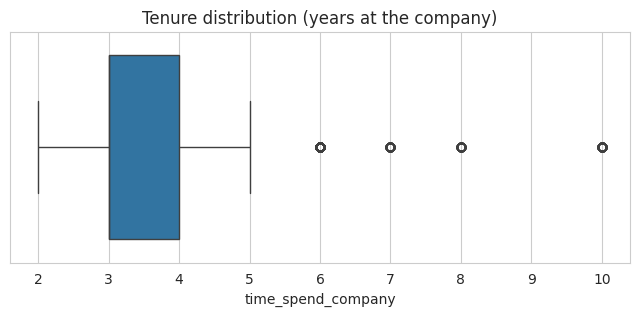

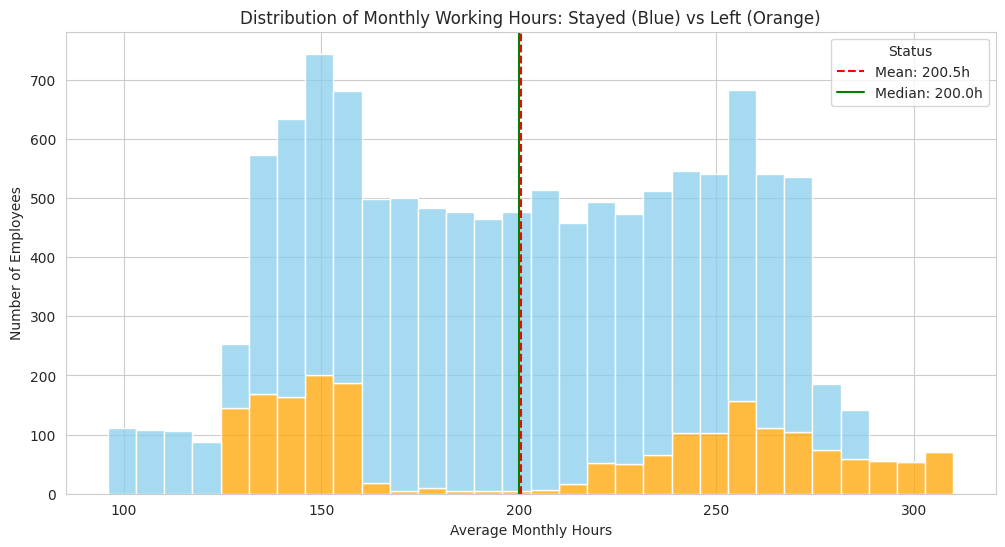

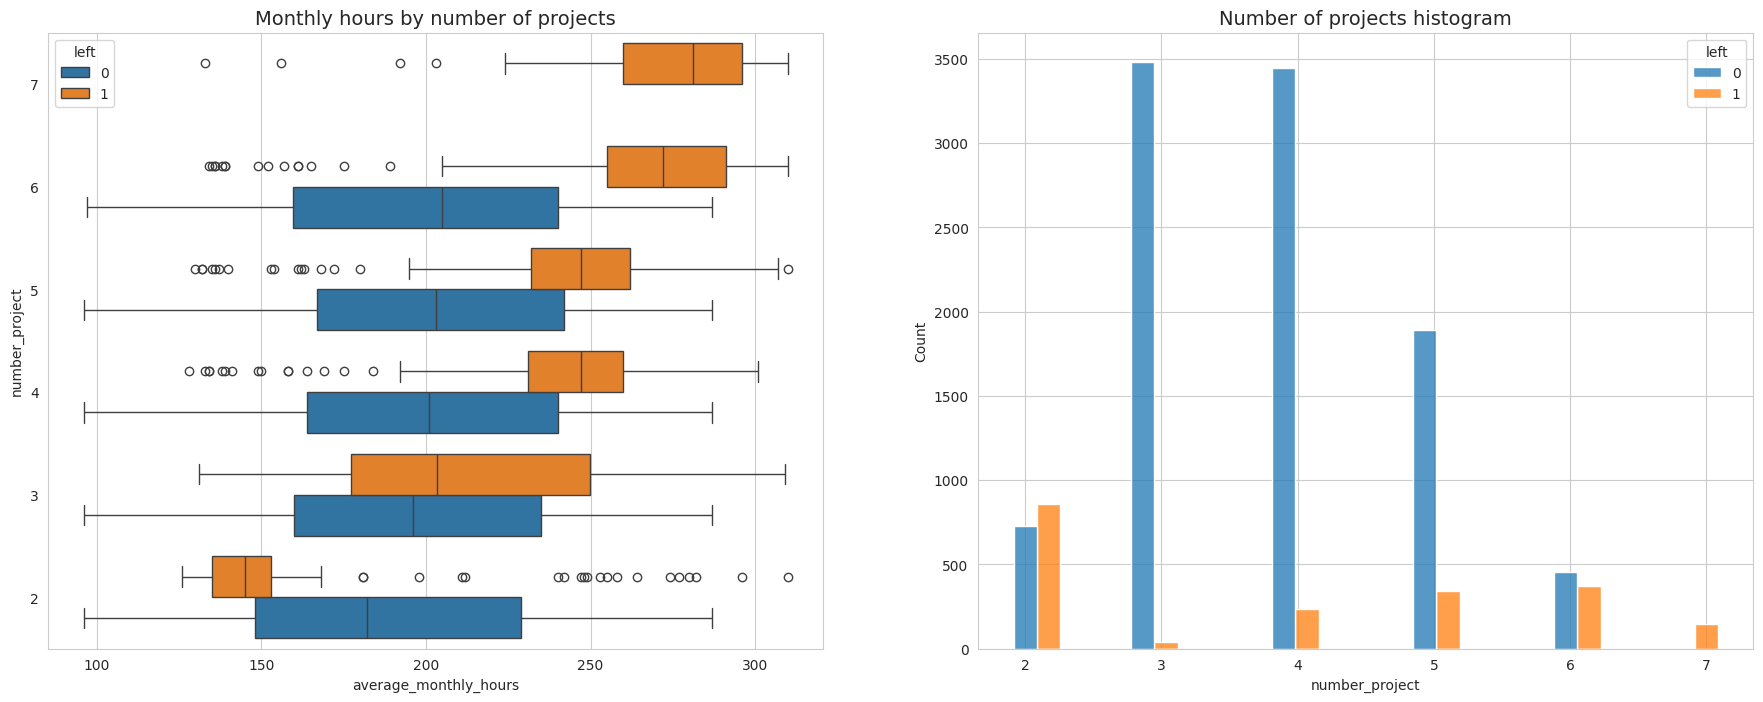

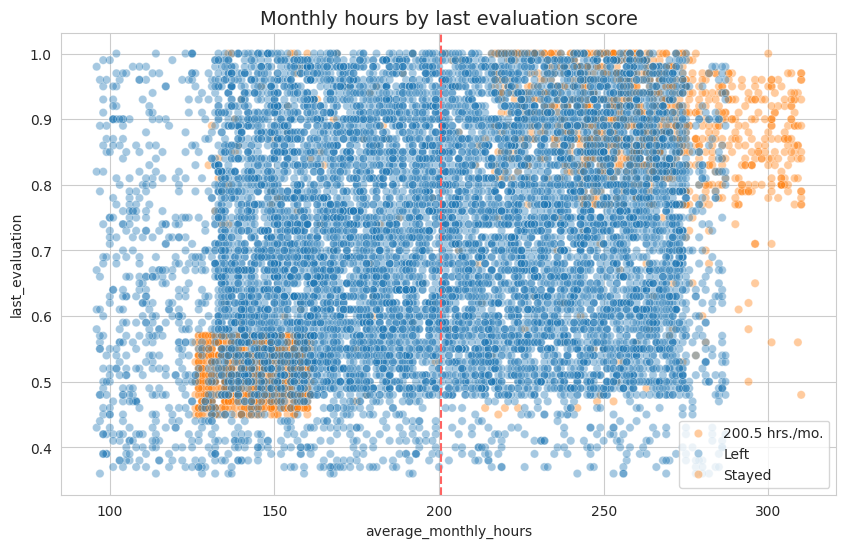

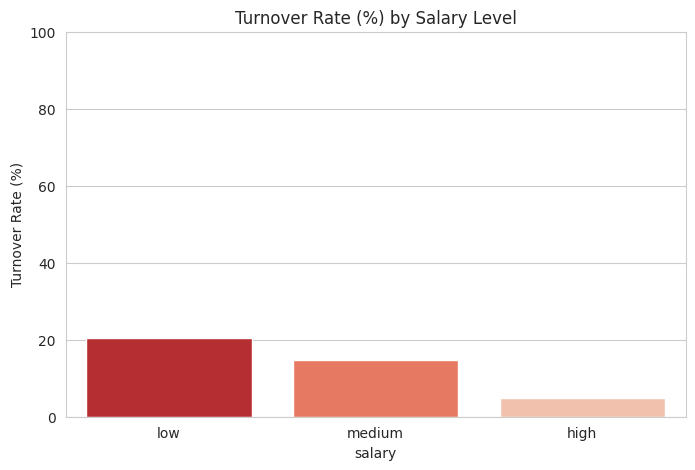

   salary  turnover_rate
0     low      20.452962
1  medium      14.616993
2    high       4.848485


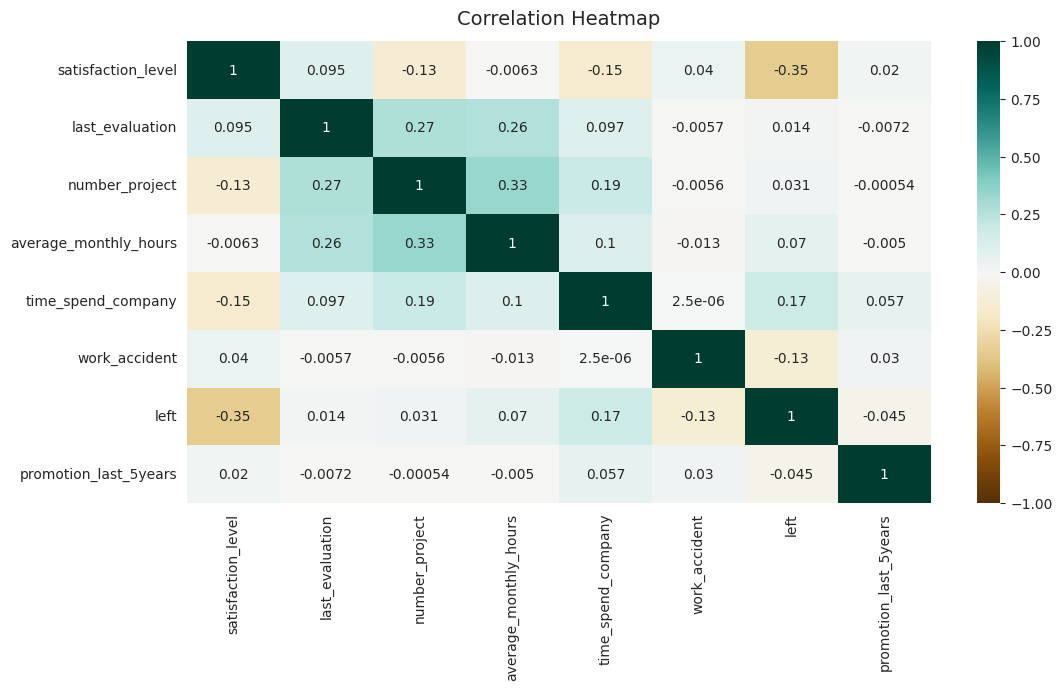

In [4]:
# ========== 3. ANALYZE - Visualizations ==========

# 1. Tenure boxplot
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='time_spend_company')
plt.title('Tenure distribution (years at the company)')
plt.show()

# 2. Monthly hours distribution by attrition status
mean_h = df['average_monthly_hours'].mean()
median_h = df['average_monthly_hours'].median()
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='average_monthly_hours', hue='left',
             palette={0: 'skyblue', 1: 'orange'}, multiple='stack', bins=30)
plt.axvline(mean_h, color='red', linestyle='--', label=f'Mean: {mean_h:.1f}h')
plt.axvline(median_h, color='green', linestyle='-', label=f'Median: {median_h:.1f}h')
plt.title('Distribution of Monthly Working Hours: Stayed (Blue) vs Left (Orange)')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Number of Employees')
plt.legend(title='Status')
plt.show()

# 3. Hours & projects - attrition profiles
fig, ax = plt.subplots(1, 2, figsize=(22, 8))
sns.boxplot(data=df, x='average_monthly_hours', y='number_project',
            hue='left', orient='h', ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize=14)
sns.histplot(data=df, x='number_project', hue='left',
             multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize=14)
plt.show()

# 4. Hours vs last evaluation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='average_monthly_hours', y='last_evaluation',
                hue='left', alpha=0.4)
plt.axvline(x=200.5, color='#ff6361', label='200.5 hrs./mo.', ls='--')
plt.legend(labels=['200.5 hrs./mo.', 'Left', 'Stayed'])
plt.title('Monthly hours by last evaluation score', fontsize=14)
plt.show()

# 5. Turnover rate by salary
turnover_rate = (df.groupby('salary')['left'].mean() * 100).reset_index()
turnover_rate.columns = ['salary', 'turnover_rate']
turnover_rate['salary'] = pd.Categorical(
    turnover_rate['salary'], categories=['low', 'medium', 'high'], ordered=True
)
turnover_rate = turnover_rate.sort_values('salary').reset_index(drop=True)
plt.figure(figsize=(8, 5))
sns.barplot(data=turnover_rate, x='salary', y='turnover_rate',
            hue='salary', palette='Reds_r', legend=False)
plt.title('Turnover Rate (%) by Salary Level')
plt.ylabel('Turnover Rate (%)')
plt.ylim(0, 100)
plt.show()
print(turnover_rate)

# 6. Correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, annot=True,
            cmap=sns.color_palette('BrBG', as_cmap=True))
plt.title('Correlation Heatmap', fontsize=14, pad=12)
plt.show()

## 💡 Key insights from EDA

### 1. Tenure — the "3-year cliff"
Tenure is concentrated between 3 and 4 years (median = 3). Employees beyond 5 years are statistical outliers → **structural difficulty retaining staff long-term**.

### 2. Monthly hours — bimodal attrition
The distribution of departures is **bimodal**: risk concentrates on both *under-utilized* employees (~150h) and *overloaded* ones (>250h).

### 3. Three attrition profiles emerge from hours × projects
- **Disengaged** (2 projects, ~140–150h) → leave due to lack of challenge
- **Intermediate risk** (3 projects) → mostly stable, leavers show hidden overwork
- **Overloaded / Burnout** (5–7 projects, 250–300h) → **critical risk, top performers**

### 4. Talent drain detected
Scatter plot reveals two clusters of leavers: **top performers (eval 0.8–1.0) working >250h/month** (burnout) and **low performers (eval ~0.5) working <150h** (role mismatch).

### 5. Salary plays a minor role
Turnover rate: **low salary = 20.5%**, medium = 14.6%, high = 4.8%. Salary matters but is not the primary driver.

### 6. 🚨 Structural bias in performance evaluation
`last_evaluation` correlates positively with `average_monthly_hours` (+0.26) and `number_project` (+0.27). The rating system **rewards quantity (presenteeism) over quality**, pushing top performers toward burnout.

In [5]:
# ========== 4. CONSTRUCT - Modeling ==========

# One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features and target
y = df_encoded['left']
X = df_encoded.drop(columns='left')

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# SMOTE on training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Resampled train shape: {X_train_res.shape}")
print(y_train_res.value_counts())

# Random Forest with GridSearchCV
rf = RandomForestClassifier(random_state=0)

cv_params = {
    'n_estimators': [75, 150, 200],
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
}

# FIX: scoring must be a LIST (not a set) in recent scikit-learn versions
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='roc_auc', n_jobs=-1)

print("\nTraining Random Forest... (this takes ~2-3 minutes)")
rf_cv.fit(X_train_res, y_train_res)

print("\nBest params:", rf_cv.best_params_)
print(f"Best CV ROC-AUC: {rf_cv.best_score_:.4f}")

Train: (9592, 18) | Test: (2399, 18)
Resampled train shape: (15998, 18)
left
0    7999
1    7999
Name: count, dtype: int64

Training Random Forest... (this takes ~2-3 minutes)

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.9971


## 🎯 Why Random Forest?

- **Robust to outliers** — crucial here since extreme values (overworked employees) are meaningful signals, not errors
- **Handles mixed feature types** naturally (categorical + continuous)
- **Provides feature importance** for business interpretation
- **Non-linear** — captures the complex interactions between workload, tenure, and satisfaction revealed in EDA

The GridSearchCV explored **96 hyperparameter combinations × 5 folds = 480 models** and selected the optimal configuration based on ROC-AUC.

Classification report on test data:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



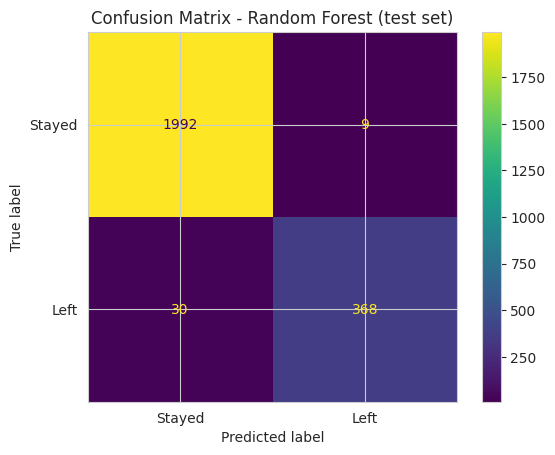

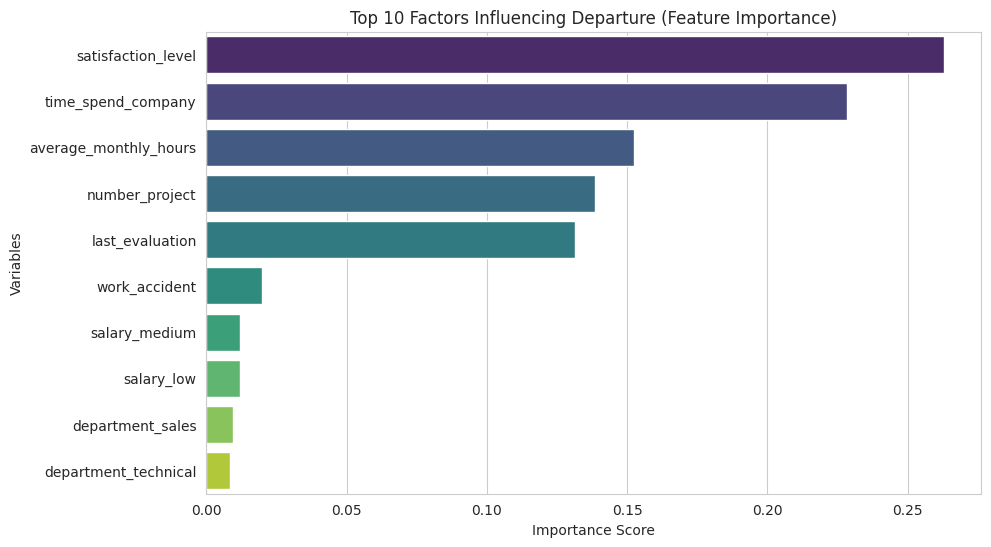

                 Variable  Importance
0      satisfaction_level    0.263144
4      time_spend_company    0.228307
3   average_monthly_hours    0.152615
2          number_project    0.138562
1         last_evaluation    0.131507
5           work_accident    0.019776
17          salary_medium    0.012005
16             salary_low    0.011988
13       department_sales    0.009466
15   department_technical    0.008530


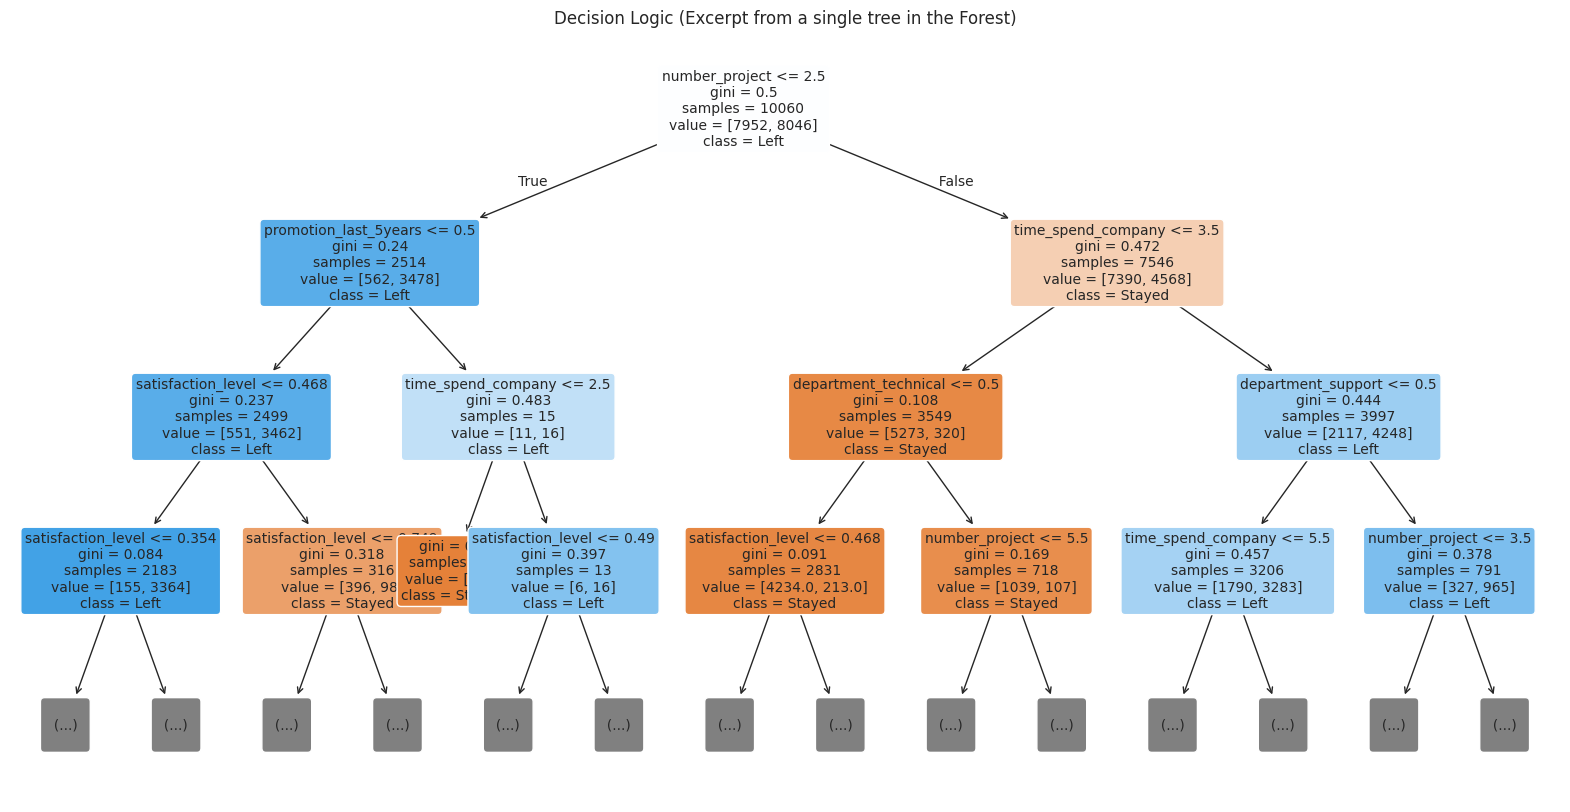

In [6]:
# ========== 5. EXECUTE - Evaluation ==========

# Predictions on test set
y_pred = rf_cv.best_estimator_.predict(X_test)

print("Classification report on test data:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_cv.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='viridis')
plt.title('Confusion Matrix - Random Forest (test set)')
plt.show()

# Feature importance
importances = rf_cv.best_estimator_.feature_importances_
df_importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importances.head(10), x='Importance', y='Variable',
            hue='Variable', palette='viridis', legend=False)
plt.title('Top 10 Factors Influencing Departure (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Variables')
plt.show()
print(df_importances.head(10))

# Decision tree excerpt
best_rf = rf_cv.best_estimator_
one_tree = best_rf.estimators_[0]
plt.figure(figsize=(20, 10))
plot_tree(
    one_tree,
    feature_names=X_train.columns,
    class_names=['Stayed', 'Left'],
    filled=True, rounded=True, fontsize=10, max_depth=3
)
plt.title('Decision Logic (Excerpt from a single tree in the Forest)')
plt.show()

## 📋 Model performance summary

| Metric | Score |
|--------|-------|
| **Accuracy** | 98% |
| **ROC-AUC** | 0.997 |
| **Recall (Left class)** | 92% |
| **Precision (Left class)** | 98% |
| **F1 (Left class)** | 0.95 |

**Test set confusion matrix:** 1,992 TN / 9 FP / 30 FN / 368 TP

The model correctly identifies **over 9 out of 10 at-risk employees** before they leave, with very few false alarms.

## 🏆 Top 5 drivers of attrition

1. `satisfaction_level` (0.263)
2. `time_spend_company` — the **3-year cliff** (0.228)
3. `average_monthly_hours` — workload pressure (0.153)
4. `number_project` (0.139)
5. `last_evaluation` (0.132)

💰 **Salary contributes marginally** → money is NOT the primary driver of churn in this context.

---

## 🚀 Business recommendations

### 1. Reform performance metrics
Decouple evaluations from hours worked to stop rewarding presenteeism. Shift focus from quantity to quality to retain top talent.

### 2. Cap workload
Hard ceiling at **200h/month** (target: 170h) to prevent burnout among high performers.

### 3. Support struggling employees
Training and technical help for employees overworking on complex projects — especially those managing 5+ projects.

### 4. Target the "3-year cliff"
Retention incentive (promotion or bonus) at the 3-year tenure mark to counter structural churn.

---

## ⚖️ Ethical considerations

- The model uses employee-provided data; predictions should be used to **improve working conditions**, never to pre-emptively terminate contracts.
- Feature importance highlights **organizational issues** (workload pressure, evaluation bias) rather than employee flaws.
- Outputs must remain a **decision-support tool for HR**, not an automated judgment system.

---

## 👤 Author

**El khlife Messoud** — Data Analyst, Nouakchott, Mauritania  
🔗 [LinkedIn](https://www.linkedin.com/in/el-khlife-messoud-153530217/) · [GitHub Portfolio](https://github.com/Khalifa160/Portfolio)